# Capítulo 18 — Soluções dos exercícios complementares

**Curso de Meteorologia Prática** — baseado em R. Stull, *Practical Meteorology* (CC BY-NC-SA 4.0).

> **Para o professor.** Soluções dos teóricos **T1–T5** e numéricos **N1–N4** do Cap. 18. Não distribuir antes da entrega.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp
import sys; sys.path.append('../comum')
from estilo_meteo import aplicar_estilo, CORES
aplicar_estilo()

g, Cp, rho, kv = 9.8, 1004.0, 1.1, 0.4
Omega = 7.292e-5

## T1 — Encroachment: $z_i \propto \sqrt{\text{calor acumulado}}$

In [2]:
# dz/dt = FH/(rho Cp gamma z)  =>  z dz = FH dt/(rho Cp gamma)
t, gam, rc = sp.symbols('t gamma rhoCp', positive=True)
z = sp.Function('z', positive=True)
FH = sp.Function('F_H')
sol = sp.dsolve(sp.Eq(z(t).diff(t), FH(t)/(rc*gam*z(t))), z(t),
                ics={z(0): sp.Symbol('z_0', positive=True)})
display(sol[1] if isinstance(sol, list) else sol)
print('=> z_i² = z_0² + (2/ρC_pγ)·∫F_H dt: a camada engole a estratificação')
print('γ na razao exata do calor que recebe. Fisicamente: aquecer a camada de')
print('0 a z_i custa a energia de "desfazer" o perfil γ ate essa altura —')
print('uma integral triangular, dai o quadrado.')

Eq(z(t), sqrt(gamma*rhoCp*(z_0**2 - 2*Integral(F_H(t), (t, 0))/(gamma*rhoCp)) + 2*Integral(F_H(t), t))/(sqrt(gamma)*sqrt(rhoCp)))

=> z_i² = z_0² + (2/ρC_pγ)·∫F_H dt: a camada engole a estratificação
γ na razao exata do calor que recebe. Fisicamente: aquecer a camada de
0 a z_i custa a energia de "desfazer" o perfil γ ate essa altura —
uma integral triangular, dai o quadrado.


## T2 — O perfil logarítmico

**Solução.** Na camada superficial a tensão turbulenta é ~constante: $\overline{u'w'} = -u_*^2$. Perto do chão, o único comprimento disponível é a própria altura $z$ (mistura de Prandtl $\ell = kz$), então
$$\frac{d\bar u}{dz} = \frac{u_*}{k\,z}\quad\Rightarrow\quad \bar u(z) = \frac{u_*}{k}\ln\frac{z}{z_0},$$
com $z_0$ a constante de integração (a altura onde $\bar u \to 0$: a rugosidade). É análise dimensional pura — a mesma lógica de Kolmogorov (T5), aplicada à parede. Estratificação corrige o perfil (funções de Monin–Obukhov), recuperando o log no caso neutro. ∎

## T3 — O orçamento de TKE

**Solução.** A energia cinética turbulenta $e = \tfrac12\overline{u_i'^2}$ obedece
$$\frac{de}{dt} = \underbrace{-\overline{u'w'}\frac{d\bar u}{dz}}_{\text{produção mecânica}} + \underbrace{\frac{g}{\theta_v}\overline{w'\theta_v'}}_{\text{produção térmica}} - \underbrace{\varepsilon}_{\text{dissipação}} + \text{transporte}.$$
- Dia: térmica positiva domina (convectivo); noite: térmica NEGATIVA consome (estável).
- A razão consumo/produção é o fluxo de Richardson $R_f$; com $R_f > 1$ a turbulência morre — o desacoplamento que liga o jato de Blackadar (Caso 4). O $Ri$ do Cap. 5 é o primo de gradiente deste critério. ∎

## T4 — A oscilação de Blackadar

In [3]:
# sem atrito: du/dt = f v ; dv/dt = -f(u-Ug). Variável complexa w = (u-Ug) + iv:
t, f_, Ug_ = sp.symbols('t f U_g', real=True)
w = sp.Function('w')
sol = sp.dsolve(sp.Eq(w(t).diff(t), -sp.I*f_*w(t)), w(t))
display(sol)
print('=> w(t) = w(0)·e^{-ift}: o vetor ageostrófico gira com período 2π/f')
print('mantendo o módulo. Pico do vento: |V|max = Ug + |w(0)| — o deficit')
print('diurno inteiro vira excesso noturno. Em 30°S: T = 2π/f ≈ 24 h/(2·0,5) ≈ 24 h;')
print('o maximo ocorre meia-volta depois (~T/2), de madrugada. ∎')

Eq(w(t), C1*exp(-I*f*t))

=> w(t) = w(0)·e^{-ift}: o vetor ageostrófico gira com período 2π/f
mantendo o módulo. Pico do vento: |V|max = Ug + |w(0)| — o deficit
diurno inteiro vira excesso noturno. Em 30°S: T = 2π/f ≈ 24 h/(2·0,5) ≈ 24 h;
o maximo ocorre meia-volta depois (~T/2), de madrugada. ∎


## T5 — Kolmogorov por análise dimensional

**Solução.** No intervalo inercial, o espectro $S(\kappa)$ só pode depender da taxa de cascata $\varepsilon$ [m²/s³] e do número de onda $\kappa$ [1/m]. Dimensionalmente $[S] = $ m³/s², e a única combinação é
$$S(\kappa) = C\,\varepsilon^{2/3}\,\kappa^{-5/3}.$$
O mesmo argumento que deu a taxa de Eady (Cap. 13) e o perfil log (T2): quando só há uma escala no problema, a física está na análise dimensional. A cascata termina na escala de Kolmogorov $\eta = (\nu^3/\varepsilon)^{1/4} \sim 1$ mm, onde a viscosidade dissipa. ∎

---
## N1 — $z_i$ da tarde: floresta × deserto

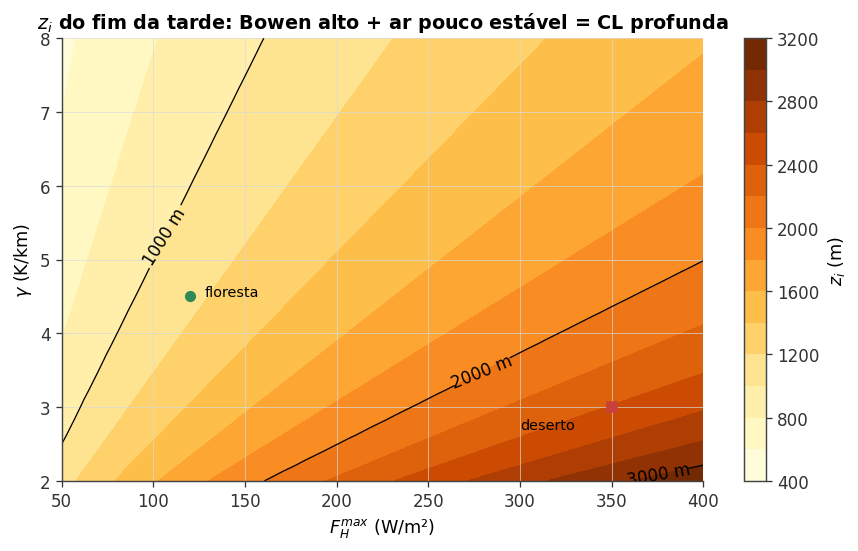

floresta (FH~120): z_i ~ 1154 m | deserto (FH~350): z_i ~ 2411 m
o deserto poe o triplo do calor sensivel: CL de 3-4 km e termicas de planador.


In [4]:
def zi_final(FH_max, gamma):
    def FH(t):
        hora = t/3600 + 6.5
        return max(FH_max*np.sin(np.pi*(hora - 7)/12), 0.0) if 7 <= hora <= 19 else 0.0
    s = solve_ivp(lambda t, zi: FH(t)/(rho*Cp*gamma*max(zi[0], 30.0)),
                  [0, 13*3600], [50.0], rtol=1e-8)
    return s.y[0][-1]

FHs = np.linspace(50, 400, 30)
gammas = np.linspace(2e-3, 8e-3, 30)
FF, GG = np.meshgrid(FHs, gammas)
ZI = np.vectorize(zi_final)(FF, GG)

fig, ax = plt.subplots(figsize=(9, 5))
cf = ax.contourf(FF, GG*1e3, ZI, levels=15, cmap='YlOrBr')
cs = ax.contour(FF, GG*1e3, ZI, levels=[1000, 2000, 3000], colors='k', linewidths=0.8)
ax.clabel(cs, fmt='%.0f m')
ax.plot(120, 4.5, 'o', color=CORES['verde']); ax.text(128, 4.5, 'floresta', fontsize=9)
ax.plot(350, 3.0, 's', color=CORES['vermelho']); ax.text(300, 2.7, 'deserto', fontsize=9)
ax.set(xlabel='$F_H^{max}$ (W/m²)', ylabel='$\\gamma$ (K/km)',
       title='$z_i$ do fim da tarde: Bowen alto + ar pouco estável = CL profunda')
fig.colorbar(cf, label='$z_i$ (m)')
plt.show()
print(f'floresta (FH~120): z_i ~ {zi_final(120, 4.5e-3):.0f} m | '
      f'deserto (FH~350): z_i ~ {zi_final(350, 3e-3):.0f} m')
print('o deserto poe o triplo do calor sensivel: CL de 3-4 km e termicas de planador.')

## N2 — Potência eólica por altura de cubo

In [5]:
u_star = 0.42
print(f'{"terreno":10s} {"60 m":>9s} {"100 m":>9s} {"150 m":>9s} {"ganho 100->150":>15s}')
for z0, nome in [(1e-4, 'mar'), (0.05, 'campo'), (1.0, 'cidade')]:
    P = [(u_star/kv*np.log(zc/z0))**3 for zc in (60, 100, 150)]
    print(f'{nome:10s} {P[0]:9.1f} {P[1]:9.1f} {P[2]:9.1f} {100*(P[2]/P[1]-1):13.1f}%')
print()
print('(unidades relativas ~u³) — na cidade, subir a torre rende 2-3x mais que')
print('no mar: quanto maior z0, mais o perfil ainda esta crescendo em 100-150 m.')
print('Offshore compensa por outro motivo: u* e o proprio vento medio maiores.')

terreno         60 m     100 m     150 m  ganho 100->150
mar           2726.4    3052.6    3329.3           9.1%
campo          412.6     508.4     594.1          16.9%
cidade          79.5     113.1     145.6          28.8%

(unidades relativas ~u³) — na cidade, subir a torre rende 2-3x mais que
no mar: quanto maior z0, mais o perfil ainda esta crescendo em 100-150 m.
Offshore compensa por outro motivo: u* e o proprio vento medio maiores.


## N3 — Reamostragem e aliasing

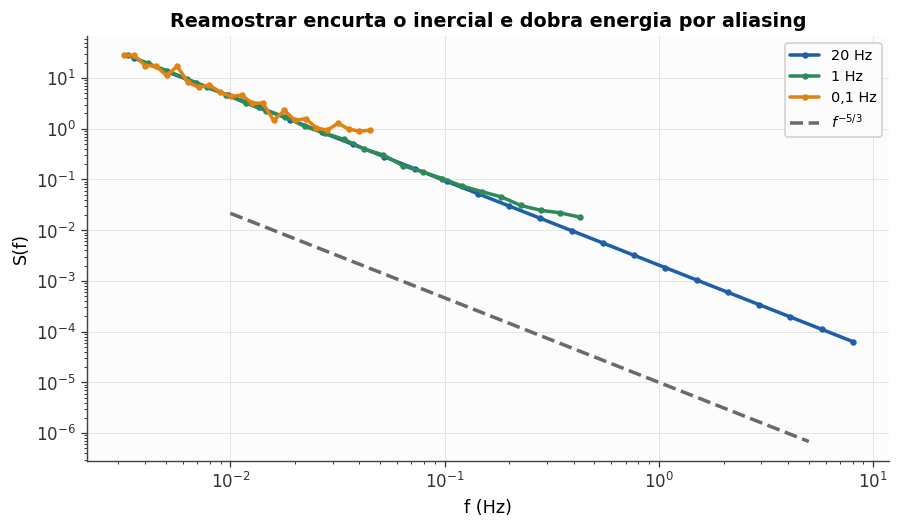

a 1 Hz perde-se tudo acima de 0,5 Hz; sem filtro anti-aliasing, essa energia
dobra para dentro do espectro (leve excesso nas ultimas bandas) — por isso
sonicos de fluxo trabalham a 10-20 Hz.


In [6]:
rng = np.random.default_rng(18)
fs, T_reg = 20.0, 3600.0
n = int(fs*T_reg)
freqs = np.fft.rfftfreq(n, 1/fs)
amp = np.zeros_like(freqs); m = freqs > 0
amp[m] = freqs[m]**(-5/6)
amp[freqs < 1/600] = amp[m][freqs[m] >= 1/600][0]
sinal = np.fft.irfft(amp*np.exp(1j*rng.uniform(0, 2*np.pi, freqs.size)), n)
sinal = 2.0 + 0.8*sinal/np.std(sinal)

fig, ax = plt.subplots(figsize=(9, 4.8))
for dec, cor, nome in [(1, CORES['azul'], '20 Hz'), (20, CORES['verde'], '1 Hz'),
                        (200, CORES['laranja'], '0,1 Hz')]:
    s_d = sinal[::dec]
    fs_d = fs/dec
    fr = np.fft.rfftfreq(s_d.size, 1/fs_d)
    S = np.abs(np.fft.rfft(s_d - s_d.mean()))**2/(fs_d*s_d.size)
    fb = np.logspace(np.log10(3e-3), np.log10(fs_d/2*0.95), 25)
    Sb = [S[(fr >= f1) & (fr < f2)].mean() for f1, f2 in zip(fb[:-1], fb[1:])]
    ax.loglog(np.sqrt(fb[:-1]*fb[1:]), Sb, 'o-', ms=3, color=cor, label=nome)
ax.loglog([1e-2, 5], [1e-1*(1e-2)**(-5/3)*1e-4, 1e-1*5**(-5/3)*1e-4], '--',
          color=CORES['cinza'], label='$f^{-5/3}$')
ax.set(xlabel='f (Hz)', ylabel='S(f)', title='Reamostrar encurta o inercial e dobra energia por aliasing')
ax.legend(fontsize=9)
plt.show()
print('a 1 Hz perde-se tudo acima de 0,5 Hz; sem filtro anti-aliasing, essa energia')
print('dobra para dentro do espectro (leve excesso nas ultimas bandas) — por isso')
print('sonicos de fluxo trabalham a 10-20 Hz.')

## N4 — O jato noturno pelo mundo

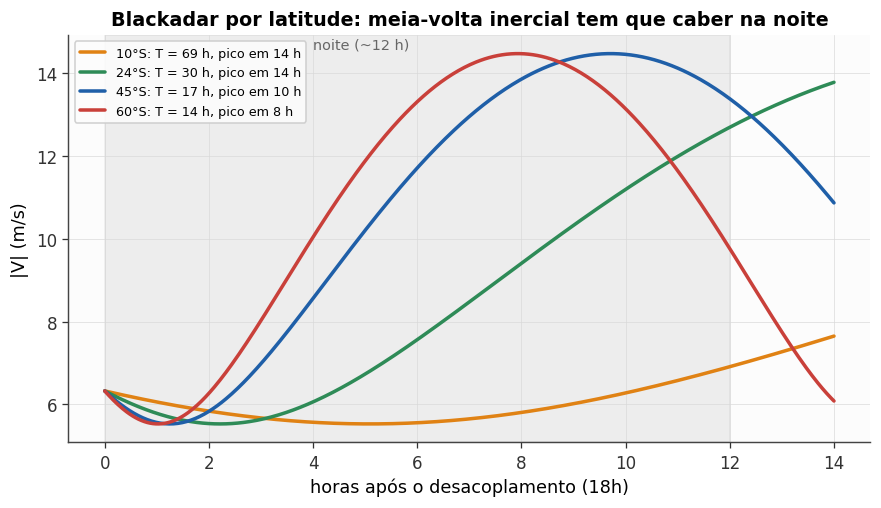

em 45-60°S a meia-volta (~7-9 h) cabe na noite: pico de madrugada ✓
em 10°S o periodo inercial e ~69 h: a noite acaba antes do jato maximo —
por isso o LLJ classico e fenomeno de latitudes medias/subtropicais.


In [7]:
Ug, u0, v0 = 10.0, 6.0, 2.0
fig, ax = plt.subplots(figsize=(9, 4.6))
for lat, cor in [(-10, CORES['laranja']), (-23.5, CORES['verde']),
                  (-45, CORES['azul']), (-60, CORES['vermelho'])]:
    f_l = 2*Omega*np.sin(np.deg2rad(lat))
    def rhs(t, y):
        return [f_l*y[1], -f_l*(y[0] - Ug)]
    t_eval = np.linspace(0, 14*3600, 500)
    s = solve_ivp(rhs, [0, 14*3600], [u0, v0], t_eval=t_eval, rtol=1e-10)
    vel = np.hypot(s.y[0], s.y[1])
    T_in = 2*np.pi/abs(f_l)/3600
    ax.plot(t_eval/3600, vel, color=cor,
            label=f'{abs(lat):.0f}°S: T = {T_in:.0f} h, pico em {t_eval[np.argmax(vel)]/3600:.0f} h')
ax.axvspan(0, 12, color=CORES['cinza'], alpha=0.1)
ax.text(4, 14.6, 'noite (~12 h)', fontsize=9, color='#666666')
ax.set(xlabel='horas após o desacoplamento (18h)', ylabel='|V| (m/s)',
       title='Blackadar por latitude: meia-volta inercial tem que caber na noite')
ax.legend(fontsize=8)
plt.show()
print('em 45-60°S a meia-volta (~7-9 h) cabe na noite: pico de madrugada ✓')
print('em 10°S o periodo inercial e ~69 h: a noite acaba antes do jato maximo —')
print('por isso o LLJ classico e fenomeno de latitudes medias/subtropicais.')

---
*Material derivado de R. Stull, Practical Meteorology (CC BY-NC-SA 4.0); este notebook herda a mesma licença.*